# Solar Spectrum Analysis Pipeline v2.5
Processing Huairou Solar Observatory spectral images (4855-4870 Å region)

## Block 1: Import & Data Loading

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import os
from pathlib import Path
from astropy.io import fits
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import wofz
import warnings
warnings.filterwarnings('ignore')

# Version control
version = 'v2.5'

# Working directory
work_dir = Path('./')
output_dir = work_dir / f'output_{version}'
output_dir.mkdir(exist_ok=True)

print(f'Pipeline version: {version}')
print(f'Output directory: {output_dir}')

# Function to load fits images
def load_fits_images(folder_path, x_range=(0, 809)):
    '''
    Load all fits images from a folder and crop to specified x range
    '''
    images = []
    fit_files = sorted(Path(folder_path).glob('*.fit'))
    
    for fit_file in fit_files:
        with fits.open(fit_file) as hdul:
            data = hdul[0].data
            # Crop: x from 0 to 809, keep all y
            cropped = data[:, x_range[0]:x_range[1]]
            images.append(cropped)
    
    print(f'Loaded {len(images)} images from {folder_path}')
    if images:
        print(f'  Image shape: {images[0].shape}')
    
    return images

# Load images
print('\n=== Loading dark images ===')
dark_images = load_fits_images(work_dir / 'dark')

print('\n=== Loading flat images ===')
flat_images = load_fits_images(work_dir / 'flat')

print('\n=== Loading norm images ===')
norm_images = load_fits_images(work_dir / 'norm')

# Stack dark images (median)
print('\n=== Creating master dark ===')
dark_master = np.median(np.array(dark_images), axis=0)
print(f'Master dark shape: {dark_master.shape}')
print(f'Dark value range: {dark_master.min():.1f} - {dark_master.max():.1f}')

# Stack flat images (mean)
print('\n=== Creating master flat ===')
flat_master = np.mean(np.array(flat_images), axis=0)
print(f'Master flat shape: {flat_master.shape}')
print(f'Flat value range: {flat_master.min():.1f} - {flat_master.max():.1f}')

# Release memory
del dark_images, flat_images
print('\nMemory released for individual dark/flat images')

# Subtract dark from flat and norm
print('\n=== Dark correction ===')
flat_corrected = flat_master - dark_master
norm_corrected = np.array([img - dark_master for img in norm_images])
print(f'Corrected flat max: {flat_corrected.max():.1f}')
print(f'Corrected norm shape: {norm_corrected.shape}')
print(f'Corrected norm value range: {norm_corrected.min():.1f} - {norm_corrected.max():.1f}')

Pipeline version: v2.5
Output directory: output_v2.5

=== Loading dark images ===
Loaded 12 images from dark
  Image shape: (992, 809)

=== Loading flat images ===
Loaded 12 images from flat
  Image shape: (992, 809)

=== Loading norm images ===
Loaded 15 images from norm
  Image shape: (992, 809)

=== Creating master dark ===
Master dark shape: (992, 809)
Dark value range: 91.0 - 331.0

=== Creating master flat ===
Master flat shape: (992, 809)
Flat value range: 145.8 - 1339.2

Memory released for individual dark/flat images

=== Dark correction ===
Corrected flat max: 1205.4
Corrected norm shape: (15, 992, 809)
Corrected norm value range: 13.0 - 1497.0


## Block 2: Tilt Fitting & Wavelength Calibration

In [2]:
# Reference spectral lines for tilt and wavelength calibration
# Ni I 4857.395 (col ~100-140), Ni I 4866.277 (col ~580-620)
ref_line1 = {'wavelength': 4857.395, 'col_range': (100, 150), 'label': 'Ni I 4857.395'}
ref_line2 = {'wavelength': 4866.277, 'col_range': (580, 630), 'label': 'Ni I 4866.277'}

def find_line_center(spectrum_col, col_center_approx, search_width=5):
    '''
    Find precise center of a spectral line in 1D spectrum
    '''
    start = max(0, col_center_approx - search_width)
    end = min(len(spectrum_col), col_center_approx + search_width + 1)
    region = spectrum_col[start:end]
    offset = np.argmin(region)  # Find minimum (absorption line)
    return start + offset

def fit_tilt(image, ref_line1, ref_line2):
    '''
    Fit spectral line tilt using two reference lines
    Returns: (slope, intercept) where y_shift = slope * x + intercept
    '''
    # Extract columns and find line centers
    col1_min, col1_max = ref_line1['col_range']
    col2_min, col2_max = ref_line2['col_range']
    
    spectrum_col1 = image[:, col1_min:col1_max].mean(axis=1)
    spectrum_col2 = image[:, col2_min:col2_max].mean(axis=1)
    
    # Find centers
    center1_y = find_line_center(spectrum_col1, image.shape[0] // 2)
    center2_y = find_line_center(spectrum_col2, image.shape[0] // 2)
    
    # Find column centers from the flat image
    row_mid = image.shape[0] // 2
    center1_x = col1_min + find_line_center(image[row_mid, col1_min:col1_max], (col1_max-col1_min)//2, (col1_max-col1_min)//2)
    center2_x = col2_min + find_line_center(image[row_mid, col2_min:col2_max], (col2_max-col2_min)//2, (col2_max-col2_min)//2)
    
    # Linear fit
    slope = (center2_y - center1_y) / (center2_x - center1_x)
    intercept = center1_y - slope * center1_x
    
    return slope, intercept, (center1_x, center1_y, center2_x, center2_y)

# Fit tilt using master flat
print('=== Fitting spectral line tilt ===')
tilt_slope, tilt_intercept, tilt_points = fit_tilt(flat_corrected, ref_line1, ref_line2)
print(f'Tilt slope: {tilt_slope:.6f} pixels/column')
print(f'Tilt intercept: {tilt_intercept:.2f}')
print(f'Reference points: {tilt_points}')

def wavelength_calibration(col, ref_line1, ref_line2, col1_center=None, col2_center=None):
    '''
    Linear wavelength calibration
    Returns wavelength given column index
    '''
    if col1_center is None:
        col1_center = (ref_line1['col_range'][0] + ref_line1['col_range'][1]) / 2
    if col2_center is None:
        col2_center = (ref_line2['col_range'][0] + ref_line2['col_range'][1]) / 2
    
    wav1 = ref_line1['wavelength']
    wav2 = ref_line2['wavelength']
    
    # Linear fit: wav = a * col + b
    a = (wav2 - wav1) / (col2_center - col1_center)
    b = wav1 - a * col1_center
    
    return a * col + b

# Wavelength calibration parameters
# Find actual column centers from flat image
row_mid = flat_corrected.shape[0] // 2
col1_center = ref_line1['col_range'][0] + find_line_center(
    flat_corrected[row_mid, ref_line1['col_range'][0]:ref_line1['col_range'][1]],
    (ref_line1['col_range'][1]-ref_line1['col_range'][0])//2,
    (ref_line1['col_range'][1]-ref_line1['col_range'][0])//2)
col2_center = ref_line2['col_range'][0] + find_line_center(
    flat_corrected[row_mid, ref_line2['col_range'][0]:ref_line2['col_range'][1]],
    (ref_line2['col_range'][1]-ref_line2['col_range'][0])//2,
    (ref_line2['col_range'][1]-ref_line2['col_range'][0])//2)
wav_a = (ref_line2['wavelength'] - ref_line1['wavelength']) / (col2_center - col1_center)
wav_b = ref_line1['wavelength'] - wav_a * col1_center

print(f'Actual column centers: ref1={col1_center:.2f}, ref2={col2_center:.2f}')
print(f'\n=== Wavelength calibration ===')
print(f'Wavelength coefficient: {wav_a:.6f} A/pixel')
print(f'Wavelength intercept: {wav_b:.3f} A')
print(f'Expected range: {wavelength_calibration(0, ref_line1, ref_line2, col1_center, col2_center):.3f} - {wavelength_calibration(809, ref_line1, ref_line2, col1_center, col2_center):.3f} A')

=== Fitting spectral line tilt ===
Tilt slope: -0.010373 pixels/column
Tilt intercept: 501.24
Reference points: (np.int64(120), np.int64(500), np.int64(602), np.int64(495))
Actual column centers: ref1=120.00, ref2=602.00

=== Wavelength calibration ===
Wavelength coefficient: 0.018427 A/pixel
Wavelength intercept: 4855.184 A
Expected range: 4855.184 - 4870.091 A


In [3]:
ref_line1, ref_line2

({'wavelength': 4857.395, 'col_range': (100, 150), 'label': 'Ni I 4857.395'},
 {'wavelength': 4866.277, 'col_range': (580, 630), 'label': 'Ni I 4866.277'})

## Block 3: Tilt & Wavelength Calibration Visualization

Saved: output_v2.5/01_tilt_wavelength_calibration_v2.5.png


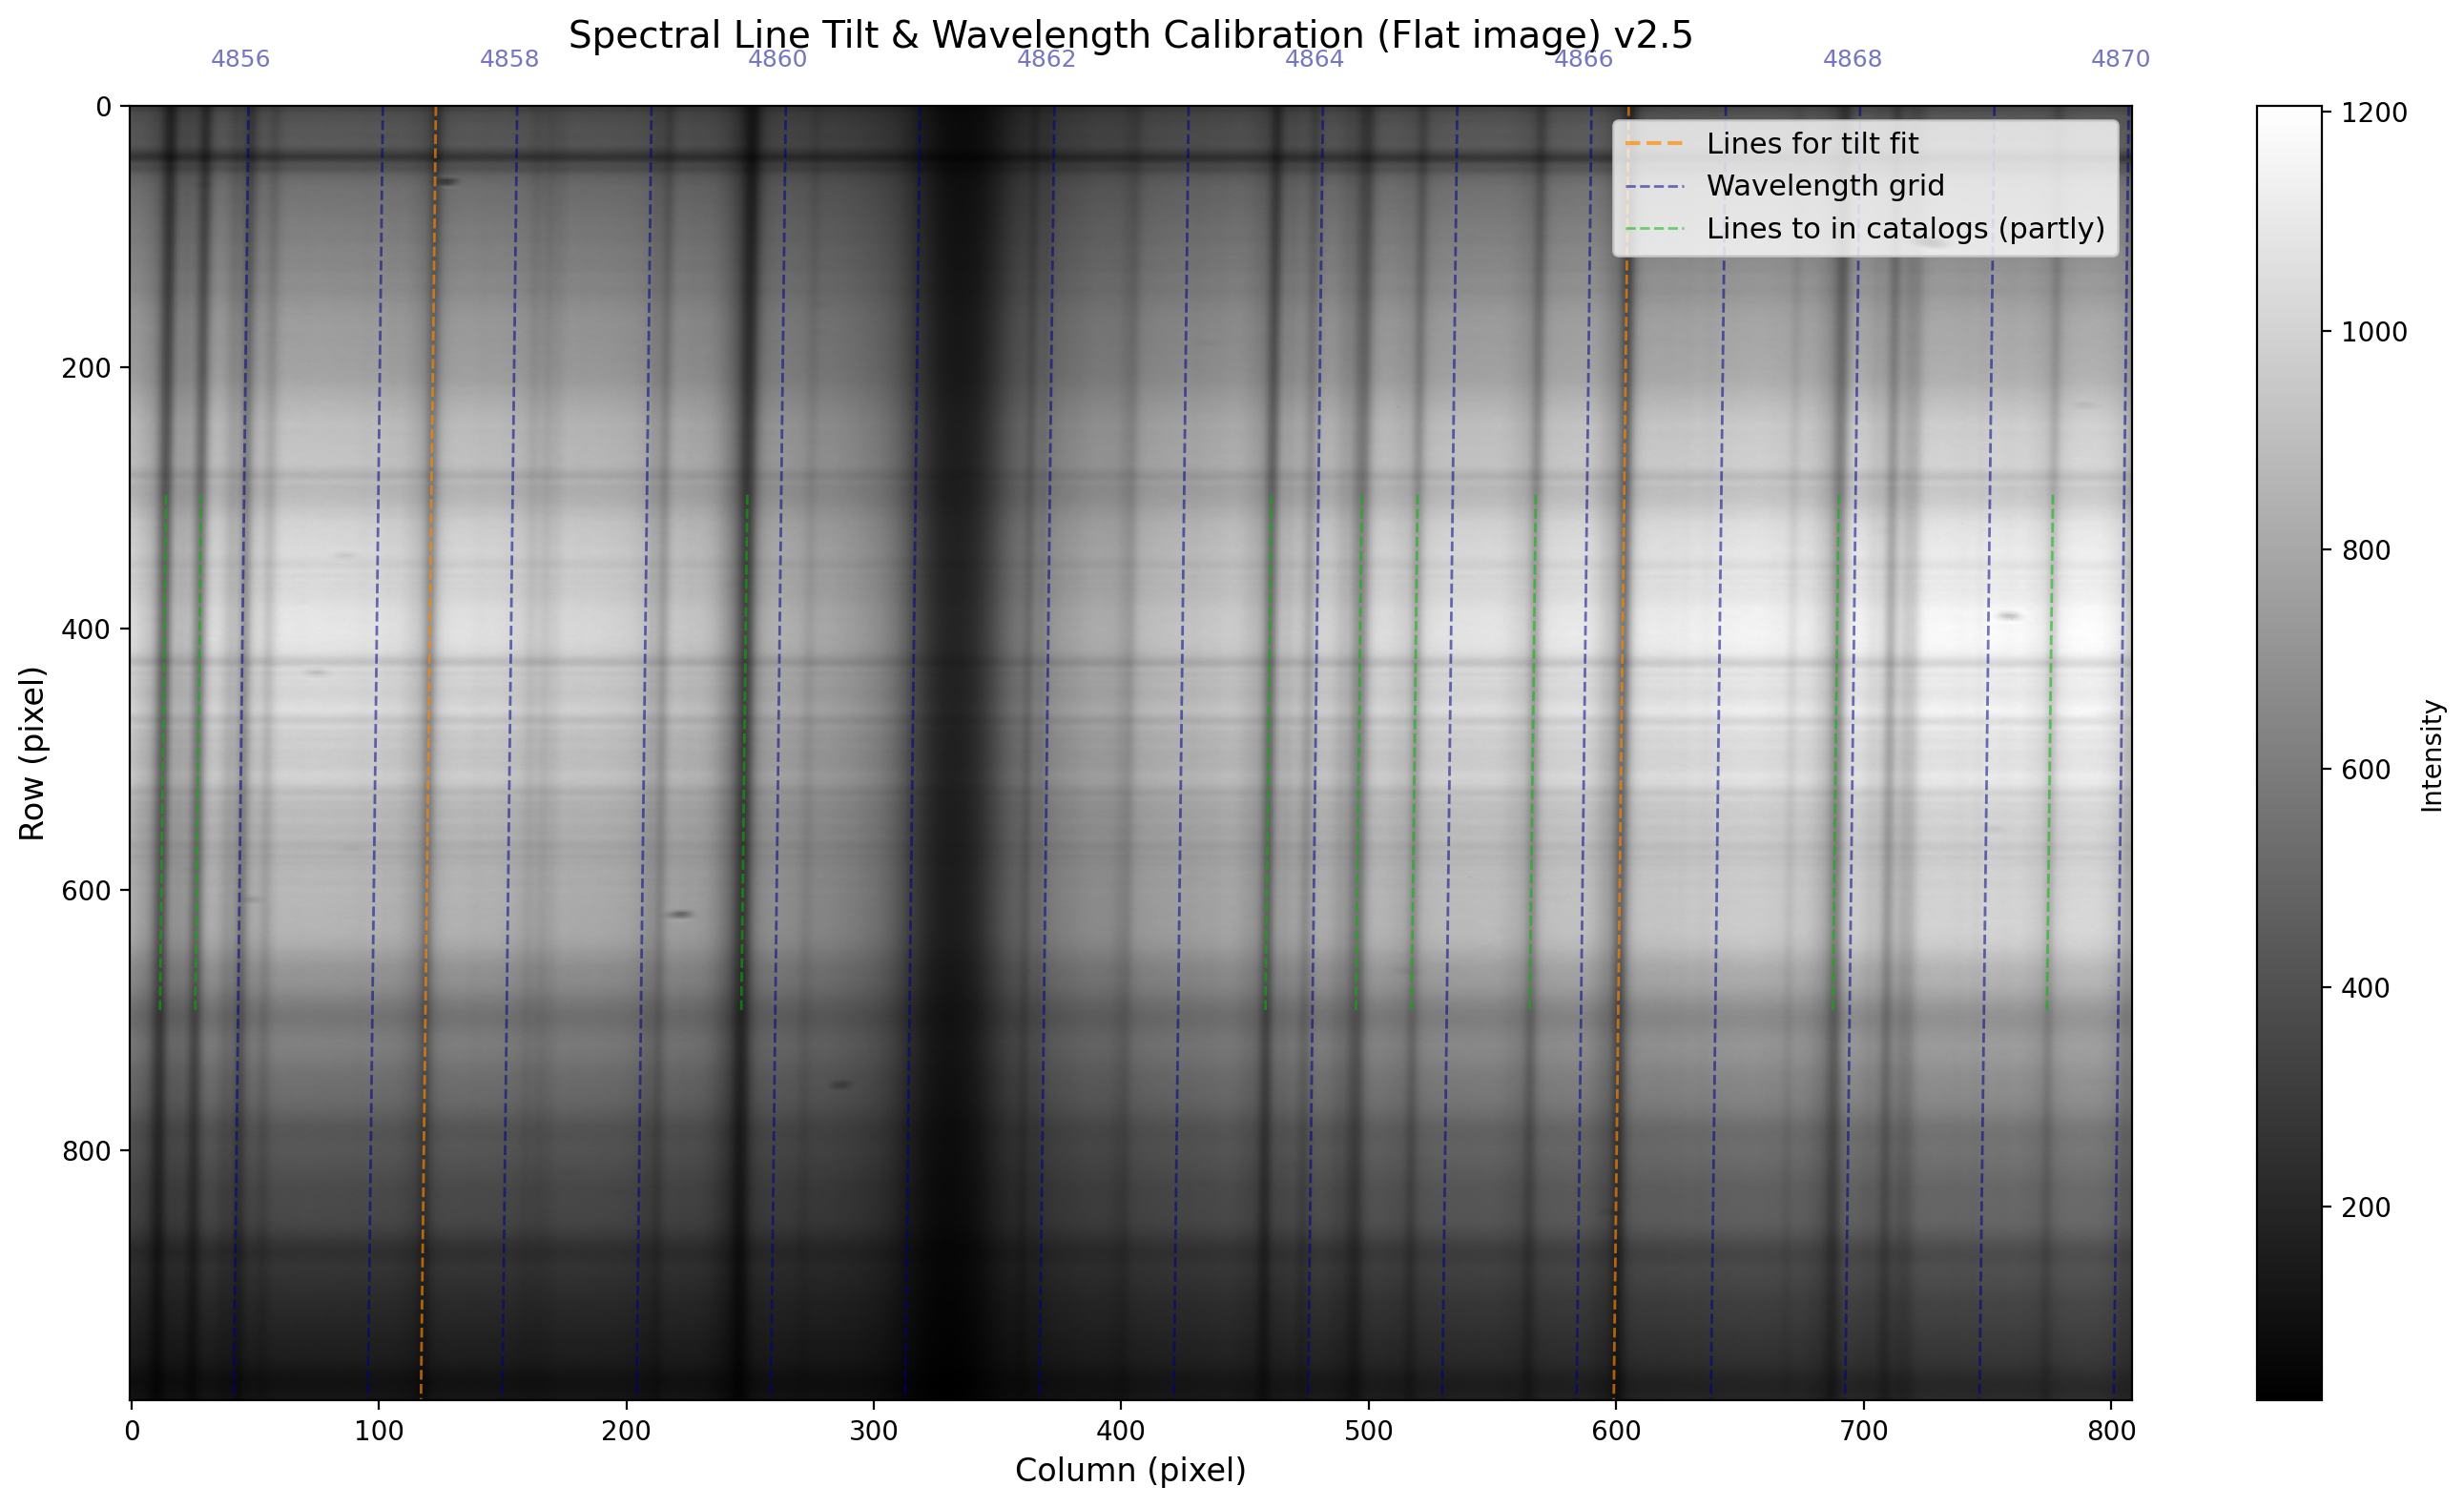

In [11]:
# Prepare display image
flat_display = flat_corrected.copy()

fig, ax = plt.subplots(figsize=(14, 8), dpi=200)

# Plot flat image as background
im = ax.imshow(flat_display, cmap='gray', origin='upper', aspect='auto')
ax.set_xlabel('Column (pixel)', fontsize=12)
ax.set_ylabel('Row (pixel)', fontsize=12)
ax.set_title(f'Spectral Line Tilt & Wavelength Calibration (Flat image) {version}\n', fontsize=14)
plt.colorbar(im, ax=ax, label='Intensity')

# Plot tilt lines (orange) on reference lines
cols = np.array([ref_line1['col_range'][0], ref_line1['col_range'][1],
                  ref_line2['col_range'][0], ref_line2['col_range'][1]])
rows_tilt = tilt_slope * cols + tilt_intercept

ncol = flat_corrected.shape[1]
nrow = flat_corrected.shape[0]
# Compute local tilt (∆col/∆row) from reference lines
tilt_local = 0.0
for cmin, cmax in [ref_line1['col_range'], ref_line2['col_range']]:
    cm = (cmin + cmax) // 2; hw = (cmax - cmin) // 2
    rs, cs = [], []
    for r in range(200, min(800, nrow), 10):
        sl = flat_corrected[r, cm - hw:cm + hw]
        cf = find_line_center(sl, hw, hw)
        if cf is not None:
            cs.append(cm - hw + cf); rs.append(r)
    if len(rs) > 5:
        tilt_local += np.polyfit(rs, cs, 1)[0]
tilt_local /= 2
for i, col_range in enumerate([ref_line1['col_range'], ref_line2['col_range']]):
    c_center = (col_range[0] + col_range[1]) / 2
    r_center = tilt_slope * c_center + tilt_intercept
    hw = (col_range[1] - col_range[0]) // 2
    row_slice = flat_corrected[int(r_center), col_range[0]:col_range[1]]
    c_line = col_range[0] + find_line_center(row_slice, hw, hw)
    ax.plot([c_line + tilt_local * (0 - r_center), c_line + tilt_local * (nrow - 1 - r_center)],
            [0, nrow - 1], '--',color='#f80a', linewidth=1)

# Plot wavelength lines (dark blue, should be parallel to orange lines)

cols_grid = np.arange(ncol)
wavelengths = wavelength_calibration(cols_grid, ref_line1, ref_line2, col1_center, col2_center)
wav_min = wavelengths.min()
wav_max = wavelengths.max()

# Draw lines for every 1 A
for wav_target in np.arange(np.ceil(wav_min), np.floor(wav_max) + 1, 1):
    # Find column corresponding to this wavelength
    col_target = (wav_target - wav_b) / wav_a
    if 0 <= col_target < ncol:
        r_c = tilt_slope * col_target + tilt_intercept
        ax.plot([col_target + tilt_local * (0 - r_c), col_target + tilt_local * (nrow - 1 - r_c)],
                [0, nrow - 1],'--', color='#0088',  linewidth=1)
        # Label every 2 A to avoid clutter
        if abs(wav_target - round(wav_target / 2) * 2) < 0.05:
            ax.text(col_target, -30, f'{wav_target:.0f}', ha='center', fontsize=9, color='#0088')

for wav_target in [4855.418, 4855.681, 4859.747, 4863.650, 4864.323, 4864.738, 4865.618, 4867.874, 4869.469]:
    col_target = (wav_target - wav_b) / wav_a
    if 0 <= col_target < ncol:
        r_c = tilt_slope * col_target + tilt_intercept
        ax.plot([col_target + tilt_local * (nrow*0.3 - r_c), 
                 col_target + tilt_local * (nrow*0.7 - r_c)],
                [nrow*0.3, nrow*0.7],'--', color='#0b08',  linewidth=1)
        
# Mark reference lines
ax.plot([], [], '--',color='#f80a', linewidth=1.5, label='Lines for tilt fit')
ax.plot([], [], '--',color='#0088', linewidth=1, label='Wavelength grid')
ax.plot([], [], '--',color='#0b08', linewidth=1, label='Lines to in catalogs (partly)')

ax.legend(loc='upper right', fontsize=11)
# ax.grid(True, alpha=0.3)

plt.tight_layout()
output_file = output_dir / f'01_tilt_wavelength_calibration_{version}.png'
plt.savefig(output_file, dpi=150, bbox_inches='tight')
print(f'Saved: {output_file}')
plt.show()
# plt.close(fig)

## Block 4: Extract 1D Spectra

In [5]:
def extract_1d_spectrum(image, tilt_slope, tilt_intercept):
    '''
    Extract 1D spectrum from 2D image by aligning to fitted tilt
    and summing along the tilted direction
    '''
    spectrum_1d = []
    
    for col in range(image.shape[1]):
        row_center = tilt_slope * col + tilt_intercept
        # Simple approach: extract a few rows around the center
        row_start = max(0, int(row_center) - 2)
        row_end = min(image.shape[0], int(row_center) + 3)
        flux = image[row_start:row_end, col].sum()
        spectrum_1d.append(flux)
    
    return np.array(spectrum_1d)

# Extract 1D spectra for all norm images
print('=== Extracting 1D spectra ===')
spectra_1d = []

for i, img in enumerate(norm_corrected):
    spec = extract_1d_spectrum(img, tilt_slope, tilt_intercept)
    spectra_1d.append(spec)

spectra_1d = np.array(spectra_1d)
print(f'Extracted {len(spectra_1d)} 1D spectra')
print(f'Spectrum shape: {spectra_1d[0].shape}')

# Crude normalization: divide by 99.9% percentile
print('\n=== Normalizing spectra ===')
spectra_normalized = np.zeros_like(spectra_1d)

for i, spec in enumerate(spectra_1d):
    p999 = np.percentile(spec, 99.9)
    spectra_normalized[i] = spec / p999

print(f'Normalized spectra shape: {spectra_normalized.shape}')
print(f'Min value: {spectra_normalized.min():.4f}, Max value: {spectra_normalized.max():.4f}')

# Wavelength array
cols_array = np.arange(spectra_normalized.shape[1])
wavelengths_array = wavelength_calibration(cols_array, ref_line1, ref_line2, col1_center, col2_center)
print(f'\nWavelength range: {wavelengths_array[0]:.3f} - {wavelengths_array[-1]:.3f} A')

=== Extracting 1D spectra ===
Extracted 15 1D spectra
Spectrum shape: (809,)

=== Normalizing spectra ===
Normalized spectra shape: (15, 809)
Min value: 0.1532, Max value: 1.0037

Wavelength range: 4855.184 - 4870.073 A


## Block 5: H-beta Line Fitting (Voigt Profile)

In [6]:
def voigt(x, x0, sigma, gamma, intensity, continuum):
    z = ((x - x0) + 1j * gamma) / (sigma * np.sqrt(2))
    profile = wofz(z).real / (sigma * np.sqrt(2 * np.pi))
    return continuum - intensity * profile / profile.max()
def moffat(x, x0, alpha, beta, depth, continuum):
    return continuum - depth * (1 + ((x - x0)/alpha)**2)**(-beta)

def identify_strong_lines(spectrum, wavelengths, mask_width=0.25):
    '''
    Identify strong absorption lines to mask during H-beta fitting
    Returns boolean mask (True = valid region for fitting)
    '''
    # Find peaks in inverted spectrum (absorption lines)
    inverted = 1.0 - spectrum
    # Use prominence-based detection
    peaks, properties = find_peaks(inverted, prominence=0.1, distance=5)
    
    mask = np.ones(len(spectrum), dtype=bool)
    
    # Mask regions around detected lines
    for peak in peaks:
        wav_peak = wavelengths[peak]
        # Exclude H-beta itself (4861.342 A) with wider margin
        if 4861.0 < wav_peak < 4861.7:
            continue
        # Mask around other lines
        mask_wav = np.abs(wavelengths - wav_peak) < mask_width
        mask &= ~mask_wav
    
    return mask

def fit_halpha(spectrum, wavelengths, hbeta_wav=4861.342):
    '''
    Fit Voigt or Moffat profile to H-beta line
    Returns: params, mask_used, fit_quality
    '''
    fit_mask = identify_strong_lines(spectrum, wavelengths)
    
    x_fit = wavelengths[fit_mask]
    y_fit = spectrum[fit_mask]
    temp_mask = x_fit < 4869.7
    x_fit = x_fit[temp_mask]
    y_fit = y_fit[temp_mask]
    
    try:
        # # Initial  x0, sigma, gamma, intensity, continuum
        # p0 = [hbeta_wav, 0.3,   3.0,       0.7,      1.0] 
        # popt, pcov = curve_fit(voigt, x_fit, y_fit, p0=p0, maxfev=5000,
        #                        bounds=([hbeta_wav-1, 0.0, 0.1, 0.1, 0.85],
        #                               [hbeta_wav+1, 2.0, 15.0, 1.0, 1.5]))
        
        p0 = [hbeta_wav, 0.8,   2.0,       0.7,      1.0] 
        popt, pcov = curve_fit(moffat, x_fit, y_fit, p0=p0, maxfev=5000,
                               bounds=([hbeta_wav-1, 0.0, 0.1, 0.1, 0.85],
                                      [hbeta_wav+1, 4.0, 15.0, 1.0, 1.5]))
                                      
        # plt.scatter(x_fit, y_fit,s=1)
        # Calculate fit quality
        y_pred = moffat(x_fit, *popt)
        residuals = y_fit - y_pred
        chi2 = np.sum(residuals**2)
        rms = np.sqrt(chi2 / len(residuals))
        
        return popt, fit_mask, {'chi2': chi2, 'rms': rms}
    except Exception as e:
        print(f'  Fitting error: {e}')
        return None, fit_mask, None

# Fit H-beta for all spectra
print('=== Fitting H-beta lines ===')
hbeta_fits = []
hbeta_masks = []
hbeta_quality = []

for i, spec in enumerate(spectra_normalized):
    # if i>0: continue
    if i % max(1, len(spectra_normalized)//10) == 0:
        print(f'Processing spectrum {i+1}/{len(spectra_normalized)}')
    
    popt, fit_mask, quality = fit_halpha(spec, wavelengths_array)
    hbeta_fits.append(popt)
    hbeta_masks.append(fit_mask)
    hbeta_quality.append(quality)

print(f'\nCompleted H-beta fitting for {len(spectra_normalized)} spectra')
successful_fits = sum(1 for f in hbeta_fits if f is not None)
print(f'Successful fits: {successful_fits}/{len(hbeta_fits)}')
print('x0 = %.6f, alpha = %.6f, beta = %.6f, \n intensity = %.6f, continuum = %.6f'%(popt[0], popt[1], popt[2], popt[3], popt[4]))

=== Fitting H-beta lines ===
Processing spectrum 1/15
Processing spectrum 2/15
Processing spectrum 3/15
Processing spectrum 4/15
Processing spectrum 5/15
Processing spectrum 6/15
Processing spectrum 7/15
Processing spectrum 8/15
Processing spectrum 9/15
Processing spectrum 10/15
Processing spectrum 11/15
Processing spectrum 12/15
Processing spectrum 13/15
Processing spectrum 14/15
Processing spectrum 15/15

Completed H-beta fitting for 15 spectra
Successful fits: 15/15
x0 = 4861.322913, alpha = 0.249830, beta = 0.249336, 
 intensity = 1.000000, continuum = 1.137509


## Block 6: Line Identification & Matching

In [7]:
# Reference spectral lines
reference_lines = {
    4855.418: 'Ni I',
    4855.681: 'Fe I',
    4856.019: 'Ti I',
    4856.195: 'Cr II',
    4857.395: 'Ni I',
    4859.039: 'Nd II',
    4859.134: 'Fe I',
    4859.747: 'Fe I',
    4860.217: 'Cr II',
    4861.849: 'Cr I',
    4863.650: 'Fe I',
    4863.936: 'Ni I',
    4864.323: 'Cr II',
    4864.738: 'V I',
    4865.618: 'Ti II',
    4866.277: 'Ni I',
    4867.537: 'Fe I',
    4867.874: 'Co I',
    4868.263: 'Ti I',
    4869.469: 'Fe I',
    4870.136: 'Ti I'
}

match_threshold = 0.05  # A

from scipy.signal import convolve
# Gaussian profile (same as yours, but cleaner usage)
def gaussian(x, x0, sigma, depth, continuum):
    return continuum - depth * np.exp(-(x - x0)**2 / (2 * sigma**2))

def gaussian_kernel(x, sigma):
    k = np.exp(-0.5 * (x / sigma) ** 2)
    return k / np.sum(k)

def identify_and_fit_lines(spectrum, wavelengths, hbeta_fit):
    """
    Matched-filter based absorption line detection + Gaussian fitting
    """

    # --------------------------------------------------
    # 1. remove Hβ using model (IMPORTANT FIX)
    # --------------------------------------------------
    if hbeta_fit is not None:
        hbeta_model = moffat(wavelengths, *hbeta_fit)
        spectrum_clean = spectrum + (1.0 - hbeta_model)
    else:
        spectrum_clean = spectrum.copy()

    # --------------------------------------------------
    # 2. absorption signal (continuum ~ 1)
    # --------------------------------------------------
    signal = 1.0 - spectrum_clean

    # --------------------------------------------------
    # 3. matched filter (kernel ~ instrumental/thermal width)
    # --------------------------------------------------
    # wavelength step
    dw = np.median(np.diff(wavelengths))

    # kernel width ~ 2-3 pixels (adjustable)
    sigma_A = 0.05  # Å (typical weak metal line width guess)
    sigma_pix = sigma_A / dw

    xk = np.arange(-10, 11)
    kernel = gaussian_kernel(xk, sigma_pix)

    response = convolve(signal, kernel, mode='same')

    # --------------------------------------------------
    # 4. peak detection on response (NOT raw flux)
    # --------------------------------------------------
    peaks, _ = find_peaks(
        response,
        prominence=np.std(response) * 0.5,
        distance=5
    )

    # --------------------------------------------------
    # 5. Gaussian fit per detected line
    # --------------------------------------------------
    lines = []

    for peak in peaks:
        wav_peak = wavelengths[peak]

        fit_width = 0.8  # Å window
        fit_mask = np.abs(wavelengths - wav_peak) < fit_width

        if np.sum(fit_mask) < 6:
            continue

        x_fit = wavelengths[fit_mask]
        y_fit = spectrum_clean[fit_mask]

        try:
            p0 = [wav_peak, 0.1, 0.2, 1.0]

            popt, _ = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=p0,
                maxfev=5000,
                bounds=(
                    [wav_peak - 0.3, 0.01, 0.001, 0.7],
                    [wav_peak + 0.3, 0.5, 0.8, 1.1]
                )
            )

            x0, sigma, depth, continuum = popt

            ew = depth * sigma * np.sqrt(2 * np.pi)

            # store result
            lines.append({
                "wavelength_meas": x0,
                "sigma": sigma,
                "depth": depth,
                "ew": ew,
                "response_peak": response[peak]
            })

        except:
            continue

    return lines


# Identify lines in all spectra
print('=== Identifying spectral lines ===')
all_lines = []

for i, spec in enumerate(spectra_normalized):
    if i % max(1, len(spectra_normalized)//10) == 0:
        print(f'Processing spectrum {i+1}/{len(spectra_normalized)}')
    
    lines = identify_and_fit_lines(spec, wavelengths_array, hbeta_fits[i])
    all_lines.append(lines)

print(f'\nLine identification complete')
print(f'Average lines per spectrum: {np.mean([len(l) for l in all_lines]):.1f}')



=== Identifying spectral lines ===
Processing spectrum 1/15
Processing spectrum 2/15
Processing spectrum 3/15
Processing spectrum 4/15
Processing spectrum 5/15
Processing spectrum 6/15
Processing spectrum 7/15
Processing spectrum 8/15
Processing spectrum 9/15
Processing spectrum 10/15
Processing spectrum 11/15
Processing spectrum 12/15
Processing spectrum 13/15
Processing spectrum 14/15
Processing spectrum 15/15

Line identification complete
Average lines per spectrum: 17.2


## Block 7: Diagnostic Plots for Each Spectrum

In [8]:
def create_spectrum_figure(spectrum, wavelengths, hbeta_fit, hbeta_mask, lines, spec_idx, version):
    '''
    Create diagnostic figure for a single spectrum
    '''

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch

    fig = plt.figure(figsize=(14, 10), dpi=200)
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.3)

    # =========================================================
    # Upper panel: H-beta fitting
    # =========================================================
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(wavelengths, spectrum, 'k-', linewidth=1, label='Spectrum')

    # --- mask regions (robust axvspan) ---
    mask = ~hbeta_mask
    i = 0
    n = len(mask)

    first_span = True
    while i < n:
        if mask[i]:
            start = wavelengths[i]
            while i < n and mask[i]:
                i += 1
            end = wavelengths[i - 1]

            ax1.axvspan(
                start, end,
                alpha=0.2,
                color='red',
                label='Masked regions' if first_span else None
            )
            first_span = False
        i += 1

    # --- Hβ model ---
    if hbeta_fit is not None:
        x_fine = np.linspace(wavelengths.min(), wavelengths.max(), 1000)
        y_fine = moffat(x_fine, *hbeta_fit)
        ax1.plot(x_fine, y_fine, 'b-', linewidth=2, label='Moffat fit (H-beta)')

    ax1.set_ylabel('Normalized Intensity', fontsize=12)
    ax1.set_title(f'Spectrum {spec_idx+1} - H-beta Fitting {version}', fontsize=13)
    ax1.legend(loc='upper right', fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1.3])
    ax1.set_xlim([wavelengths.min(), wavelengths.max()])

    # =========================================================
    # Lower panel: line identification
    # =========================================================
    ax2 = fig.add_subplot(gs[1])

    # --- Hβ-subtracted spectrum ---
    spectrum_sub = spectrum.copy()
    if hbeta_fit is not None:
        spectrum_sub = spectrum - (moffat(wavelengths, *hbeta_fit) - 1.0)

    ax2.plot(wavelengths, spectrum_sub, 'k-', linewidth=1, label='H-beta corrected')

    # =========================================================
    # ✔ enrichment step (reference matching inside plot cell)
    # =========================================================
    for line in lines:
        if 'element' not in line or line['element'] is None:
            x0 = line['wavelength_meas']

            element = None
            delta_wav = None
            delta_v = None
            ref_wav_used = None

            for ref_wav, elem in reference_lines.items():
                if abs(x0 - ref_wav) < match_threshold:
                    element = elem
                    delta_wav = x0 - ref_wav
                    delta_v = (delta_wav / ref_wav) * 3e5
                    ref_wav_used = ref_wav
                    break

            line['element'] = element
            line['delta_wav'] = delta_wav
            line['delta_v'] = delta_v
            line['reference_wav'] = ref_wav_used

    # --- colors ---
    colors = [
        'C1' if line.get('element', None) is not None else 'C2'
        for line in lines
    ]

    # =========================================================
    # plot lines + labels
    # =========================================================
    for i, line in enumerate(lines):

        wav = line['wavelength_meas']
        idx = np.argmin(np.abs(wavelengths - wav))
        y = spectrum_sub[idx]

        ax2.plot(wav, y, 'o', color=colors[i], markersize=6)

        label_text = f'{wav:.3f}'

        if line.get('element', None) is not None:
            dv = line.get('delta_v', None)
            dv_str = f'{dv:.1f}' if dv is not None else 'N/A'
            label_text += f"\n{line['element']}\nΔv={dv_str} km/s"

        ax2.text(
            wav,
            y - 0.08,
            label_text,
            ha='center',
            fontsize=8
        )

    ax2.set_xlabel('Wavelength (A)', fontsize=12)
    ax2.set_ylabel('Normalized Intensity', fontsize=12)
    ax2.set_title('Line Identification and Matching', fontsize=13)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.3])
    ax2.set_xlim([wavelengths.min(), wavelengths.max()])

    # legend
    legend_elements = [
        Patch(facecolor='C1', label='Matched to reference'),
        Patch(facecolor='C2', label='Unmatched')
    ]
    ax2.legend(handles=legend_elements, loc='upper right', fontsize=10)

    plt.tight_layout()
    return fig

# Generate figures for first few spectra and sample throughout
print('=== Generating diagnostic plots ===')
n_spectra_to_plot = min(5, len(spectra_normalized))
indices_to_plot = np.linspace(0, len(spectra_normalized)-1, n_spectra_to_plot, dtype=int)

indices_to_plot = np.arange(len(spectra_normalized))

for idx in indices_to_plot:
    fig = create_spectrum_figure(spectra_normalized[idx], wavelengths_array,
                                 hbeta_fits[idx], hbeta_masks[idx],
                                 all_lines[idx], idx, version)
    
    output_file = output_dir / f'02_spectrum_{idx:03d}_{version}.png'
    fig.savefig(output_file, dpi=150, bbox_inches='tight')
    print(f'Saved: {output_file}')
    plt.close(fig)

print(f'\nGenerated diagnostic plots for {len(indices_to_plot)} spectra')

=== Generating diagnostic plots ===
Saved: output_v2.5/02_spectrum_000_v2.5.png
Saved: output_v2.5/02_spectrum_001_v2.5.png
Saved: output_v2.5/02_spectrum_002_v2.5.png
Saved: output_v2.5/02_spectrum_003_v2.5.png
Saved: output_v2.5/02_spectrum_004_v2.5.png
Saved: output_v2.5/02_spectrum_005_v2.5.png
Saved: output_v2.5/02_spectrum_006_v2.5.png
Saved: output_v2.5/02_spectrum_007_v2.5.png
Saved: output_v2.5/02_spectrum_008_v2.5.png
Saved: output_v2.5/02_spectrum_009_v2.5.png
Saved: output_v2.5/02_spectrum_010_v2.5.png
Saved: output_v2.5/02_spectrum_011_v2.5.png
Saved: output_v2.5/02_spectrum_012_v2.5.png
Saved: output_v2.5/02_spectrum_013_v2.5.png
Saved: output_v2.5/02_spectrum_014_v2.5.png

Generated diagnostic plots for 15 spectra


## Block 8: Output All Spectra to FITS File

In [9]:
def create_fits_output(spectra, wavelengths, hbeta_fits, all_lines, output_path):
    '''
    Create FITS file with all spectra and metadata for TOPCAT
    '''
    # Create primary HDU
    hdu_primary = fits.PrimaryHDU()
    hdu_primary.header['VERSION'] = version
    hdu_primary.header['COMMENT'] = 'Solar spectrum analysis pipeline output'
    hdu_primary.header['TELESCOP'] = 'Hainan Solar Observatory'
    hdu_primary.header['WAVELMIN'] = wavelengths.min()
    hdu_primary.header['WAVELMAX'] = wavelengths.max()
    hdu_primary.header['NSPEC'] = len(spectra)
    
    # Create HDU for wavelength array
    hdu_wavelength = fits.BinTableHDU.from_columns([
        fits.Column(name='WAVELENGTH', format='E', array=wavelengths)
    ])
    hdu_wavelength.header['EXTNAME'] = 'WAVELENGTH'
    
    # Create HDU for spectra
    cols = []
    for i in range(len(spectra)):
        cols.append(fits.Column(name=f'SPEC_{i:03d}', format='E', array=spectra[i]))
    hdu_spectra = fits.BinTableHDU.from_columns(cols)
    hdu_spectra.header['EXTNAME'] = 'SPECTRA'
    
    # Create HDU for line catalog
    n_lines_max = max([len(lines) for lines in all_lines]) if all_lines else 0
    
    spectrum_ids = []
    wavelengths_meas = []
    elements = []
    sigmas = []
    depths = []
    ews = []
    delta_wavs = []
    delta_vs = []
    
    for spec_idx, lines in enumerate(all_lines):
        for line in lines:
            spectrum_ids.append(spec_idx)
            wavelengths_meas.append(line['wavelength_meas'])
            elements.append(line['element'] if line['element'] else 'Unknown')
            sigmas.append(line['sigma'])
            depths.append(line['depth'])
            ews.append(line['ew'])
            delta_wavs.append(line['delta_wav'] if line['delta_wav'] else np.nan)
            delta_vs.append(line['delta_v'] if line['delta_v'] else np.nan)
    
    hdu_lines = fits.BinTableHDU.from_columns([
        fits.Column(name='SPEC_ID', format='J', array=np.array(spectrum_ids, dtype=int)),
        fits.Column(name='WAVELENGTH', format='E', array=np.array(wavelengths_meas)),
        fits.Column(name='ELEMENT', format='20A', array=np.array(elements)),
        fits.Column(name='SIGMA', format='E', array=np.array(sigmas)),
        fits.Column(name='DEPTH', format='E', array=np.array(depths)),
        fits.Column(name='EW', format='E', array=np.array(ews)),
        fits.Column(name='DELTA_WAV', format='E', array=np.array(delta_wavs)),
        fits.Column(name='DELTA_V', format='E', array=np.array(delta_vs))
    ])
    hdu_lines.header['EXTNAME'] = 'LINES'
    hdu_lines.header['COMMENT'] = 'Line catalog for all spectra'
    
    # Write to file
    hdul = fits.HDUList([hdu_primary, hdu_wavelength, hdu_spectra, hdu_lines])
    hdul.writeto(output_path, overwrite=True)
    print(f'Saved FITS file: {output_path}')
    hdul.info()

# Create output FITS file
print('=== Creating FITS output file ===')
fits_output_path = output_dir / f'solar_spectra_{version}.fits'
create_fits_output(spectra_normalized, wavelengths_array, hbeta_fits, all_lines, fits_output_path)

print(f'\n=== Pipeline Complete ===')
print(f'Output directory: {output_dir}')
print(f'Total spectra processed: {len(spectra_normalized)}')
print(f'Output files:')
for f in sorted(output_dir.glob('*')):
    size_mb = f.stat().st_size / (1024*1024)
    print(f'  - {f.name} ({size_mb:.2f} MB)')

=== Creating FITS output file ===
Saved FITS file: output_v2.5/solar_spectra_v2.5.fits
Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      10   ()      
  1  WAVELENGTH    1 BinTableHDU     11   809R x 1C   ['E']   
  2  SPECTRA       1 BinTableHDU     39   809R x 15C   ['E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E']   
  3  LINES         1 BinTableHDU     26   258R x 8C   ['J', 'E', '20A', 'E', 'E', 'E', 'E', 'E']   

=== Pipeline Complete ===
Output directory: output_v2.5
Total spectra processed: 15
Output files:
  - 01_tilt_wavelength_calibration_v2.5.png (0.73 MB)
  - 02_spectrum_000_v2.5.png (0.20 MB)
  - 02_spectrum_001_v2.5.png (0.21 MB)
  - 02_spectrum_002_v2.5.png (0.21 MB)
  - 02_spectrum_003_v2.5.png (0.21 MB)
  - 02_spectrum_004_v2.5.png (0.21 MB)
  - 02_spectrum_005_v2.5.png (0.21 MB)
  - 02_spectrum_006_v2.5.png (0.20 MB)
  - 02_spectrum_007_v2.5.png

## Summary and Statistics

In [10]:
# Generate summary statistics
print('\n' + '='*60)
print(f'PIPELINE SUMMARY - Version {version}')
print('='*60)

print('\n1. DATA LOADING')
print(f'   Dark images stacked: median of images')
print(f'   Flat images stacked: mean of images')
print(f'   Norm images: {len(norm_corrected)} total')
print(f'   Crop region: x=0-809, y=all')
print(f'   Image shape: {norm_corrected[0].shape}')

print('\n2. TILT & WAVELENGTH CALIBRATION')
print(f'   Reference lines: Ni I 4857.395, Ni I 4866.277')
print(f'   Tilt slope: {tilt_slope:.6f} pixels/column')
print(f'   Tilt intercept: {tilt_intercept:.2f} pixels')
print(f'   Wavelength range: {wavelengths_array.min():.3f} - {wavelengths_array.max():.3f} A')
print(f'   Wavelength scale: {wav_a:.6f} A/pixel')

print('\n3. 1D SPECTRUM EXTRACTION')
print(f'   Total spectra: {len(spectra_normalized)}')
print(f'   Spectrum length: {spectra_normalized.shape[1]} pixels')
print(f'   Normalization method: 99.9% percentile')

print('\n4. H-BETA FITTING')
hbeta_success = sum(1 for f in hbeta_fits if f is not None)
print(f'   Successful fits: {hbeta_success}/{len(hbeta_fits)}')
print(f'   Profile: Voigt')
print(f'   Target wavelength: 4861.342 A')

print('\n5. LINE IDENTIFICATION')
total_lines = sum(len(lines) for lines in all_lines)
matched_lines = sum(sum(1 for line in lines if line['element'] is not None) for lines in all_lines)
print(f'   Total lines identified: {total_lines}')
print(f'   Matched to reference: {matched_lines}')
print(f'   Matching threshold: {match_threshold} A')
print(f'   Reference lines: {len(reference_lines)}')

print('\n6. OUTPUT FILES')
output_files = list(output_dir.glob('*'))
print(f'   Total files: {len(output_files)}')
total_size = sum(f.stat().st_size for f in output_files) / (1024*1024)
print(f'   Total size: {total_size:.2f} MB')

print('\n' + '='*60)


PIPELINE SUMMARY - Version v2.5

1. DATA LOADING
   Dark images stacked: median of images
   Flat images stacked: mean of images
   Norm images: 15 total
   Crop region: x=0-809, y=all
   Image shape: (992, 809)

2. TILT & WAVELENGTH CALIBRATION
   Reference lines: Ni I 4857.395, Ni I 4866.277
   Tilt slope: -0.010373 pixels/column
   Tilt intercept: 501.24 pixels
   Wavelength range: 4855.184 - 4870.073 A
   Wavelength scale: 0.018427 A/pixel

3. 1D SPECTRUM EXTRACTION
   Total spectra: 15
   Spectrum length: 809 pixels
   Normalization method: 99.9% percentile

4. H-BETA FITTING
   Successful fits: 15/15
   Profile: Voigt
   Target wavelength: 4861.342 A

5. LINE IDENTIFICATION
   Total lines identified: 258
   Matched to reference: 190
   Matching threshold: 0.05 A
   Reference lines: 21

6. OUTPUT FILES
   Total files: 17
   Total size: 3.89 MB

